In [1]:
import pandas as pd
import random
import numpy as np

# 01. Gerando os dados

In [2]:
# Para esse exercícios, quero criar um dataset artificial de duas features, com
# três clusters bem definidos, para que eu possa observar o comportamento
# do K-Means e depois comparar com outros métodos
feat1_mean = [10, 10]
feat2_mean = [10, 55]
feat3_mean = [40, 10]

df = pd.DataFrame(columns=["feat1", "feat2"])
n_samples_cluster = 100
for i in range(n_samples_cluster):
    c1 = [random.gauss(feat1_mean[0], 5), random.gauss(feat1_mean[1], 5)]
    c2 = [random.gauss(feat2_mean[0], 5), random.gauss(feat2_mean[1], 5)]
    c3 = [random.gauss(feat3_mean[0], 5), random.gauss(feat3_mean[1], 5)]

    df.loc[len(df)] = [c1[0], c1[1]]
    df.loc[len(df)] = [c2[0], c2[1]]
    df.loc[len(df)] = [c3[0], c3[1]]

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   feat1   300 non-null    float64
 1   feat2   300 non-null    float64
dtypes: float64(2)
memory usage: 7.0 KB


In [4]:
df.describe()

,feat1,feat2
count,300.000000,300.000000
mean,19.640875,24.674678
std,14.920863,22.010247
min,-1.839116,-5.850873
25%,8.163159,8.322840
50%,13.011644,12.933415
75%,36.056970,50.327573
max,50.619382,66.722957


In [5]:
# Para este exercício, quero supersimplificar o problema e usar apenas duas features
# para que possa observar o comportamento do algoritmo com um plot
variables = [
    "feat1",
    "feat2"
]

df_x = df[variables]
X = df_x.values

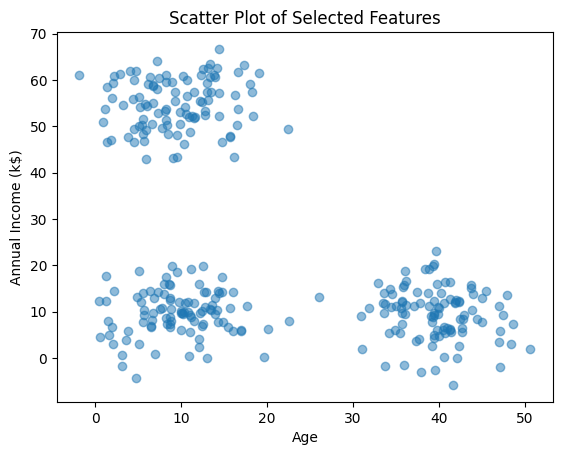

In [6]:
# Scatter plot das features selecionadas
import matplotlib.pyplot as plt

plt.scatter(df_x['feat1'], df_x['feat2'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Scatter Plot of Selected Features')
plt.show()

# 02. Construção do Modelo

In [7]:
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Função para calcular os centróides dos clusters
def calculate_centroids(clusters):
    centroids = []
    for cluster in clusters:
        centroid = np.mean(cluster, axis=0)
        centroids.append(centroid)
    return np.array(centroids)

In [8]:
k = 3  # Número de clusters

init = [random.randint(0, len(X) - 1) for _ in range(k)] # Posição inicial dos clusters
df_x.loc[:, 'cluster'] = -1  # Inicializa a coluna de cluster com -1
df_x.loc[init, 'cluster'] = range(k)  # Atribui os clusters iniciais aos pontos selecionados

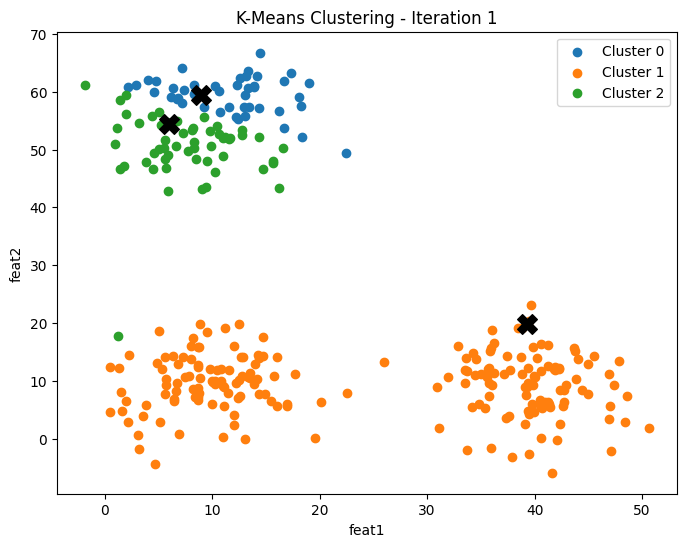

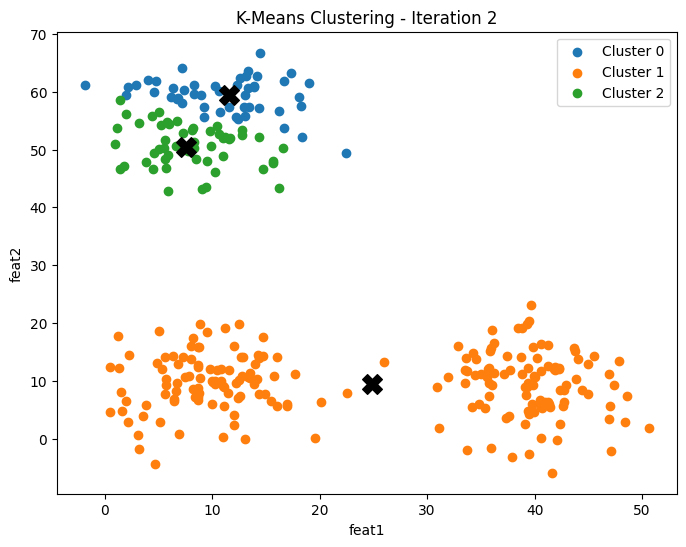

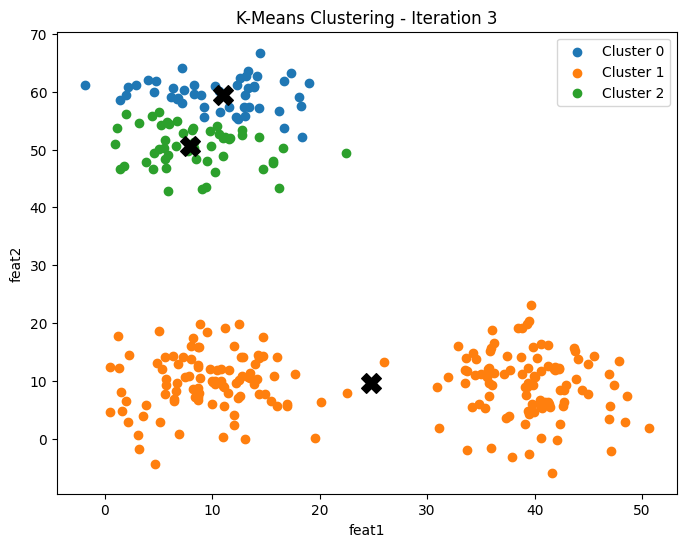

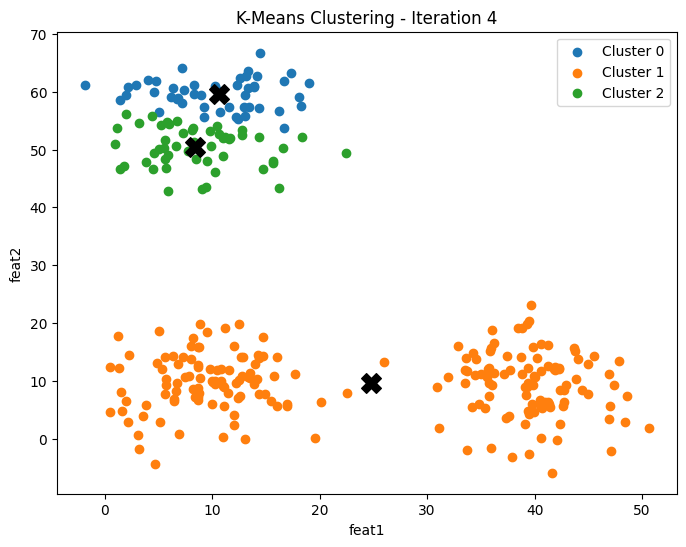

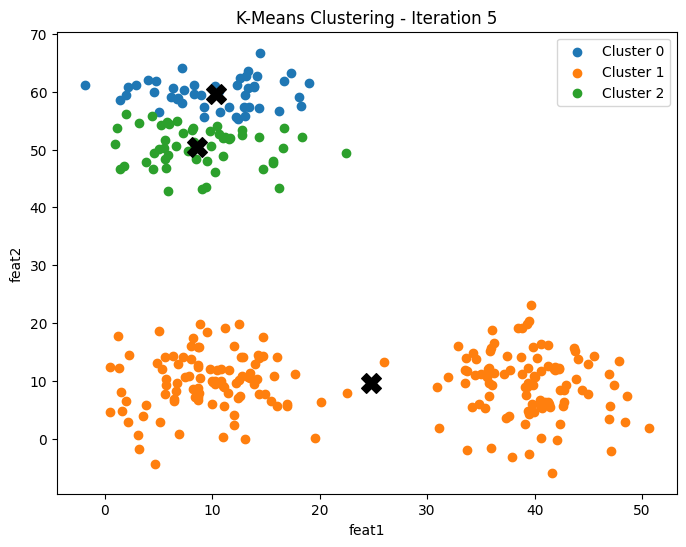

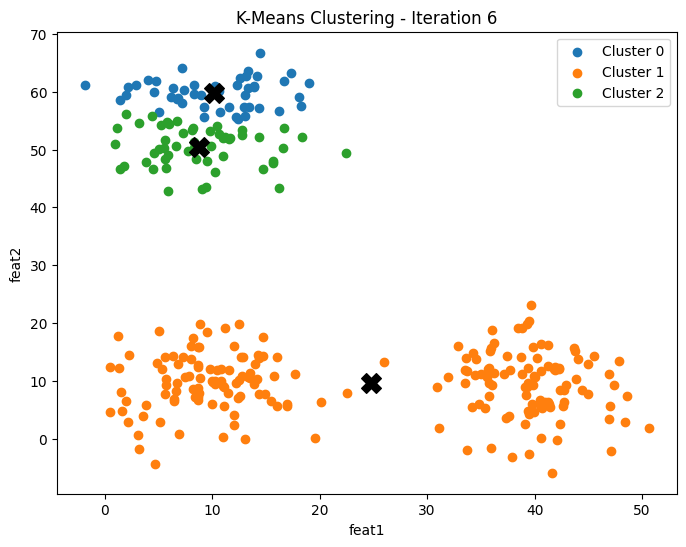

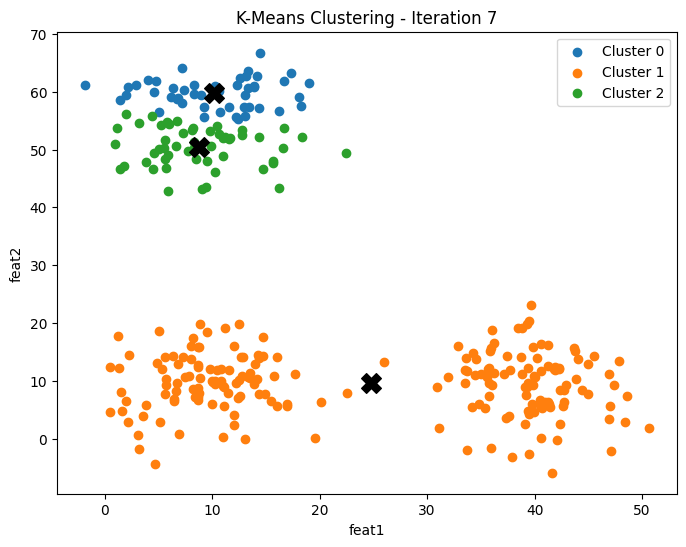

Converged after 7 iterations.


In [9]:
# Aplicar estratégia de K-Means
centroids_memory = [-1, -1, -1]  # Inicializa a memória dos centróides para verificar convergência

for iteration in range(10):  # Número de iterações
    # Calcular os centróides dos clusters
    centroids = calculate_centroids([X[df_x['cluster'] == i] for i in range(k)])

    # Atribuir cada ponto ao cluster mais próximo
    for index, row in df_x.iterrows():
        distances = [euclidean_distance(row[variables].values, centroids[i]) for i in range(k)]
        df_x.at[index, 'cluster'] = np.argmin(distances)

    # Plotar os clusters e centróides
    plt.figure(figsize=(8, 6))
    for i in range(k):
        cluster_points = df_x[df_x['cluster'] == i]
        plt.scatter(cluster_points['feat1'], cluster_points['feat2'], label=f'Cluster {i}')
        plt.scatter(centroids[i][0], centroids[i][1], marker='X', s=200, c='black')  # Centróide

    plt.xlabel('feat1')
    plt.ylabel('feat2')
    plt.title(f'K-Means Clustering - Iteration {iteration + 1}')
    plt.legend()
    plt.show()

    # Verificar se os centróides mudaram
    if np.array_equal(centroids, centroids_memory):
        print(f"Converged after {iteration + 1} iterations.")
        break

    centroids_memory = centroids

# 03. Tentar quebrar o K-Means com um mini cluster próximo a outro cluster

In [10]:
n_samples_mini_cluster = 30
for i in range(n_samples_mini_cluster):
    c4 = [random.gauss(40, 3), random.gauss(35, 3)]
    df_x.loc[len(df_x)] = [c4[0], c4[1], -1]  # Adiciona novos pontos sem cluster

X = df_x[["feat1", "feat2"]].values

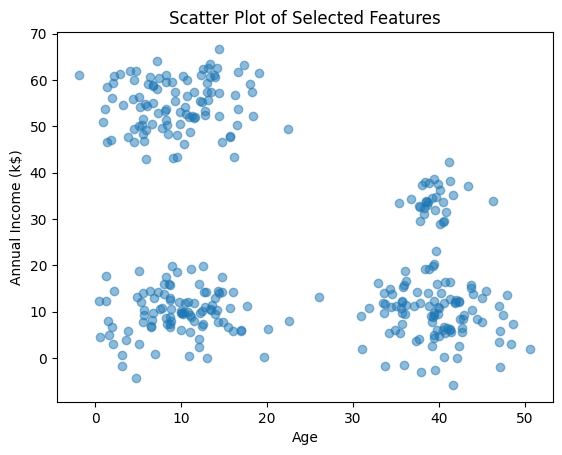

In [11]:
plt.scatter(df_x['feat1'], df_x['feat2'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Scatter Plot of Selected Features')
plt.show()

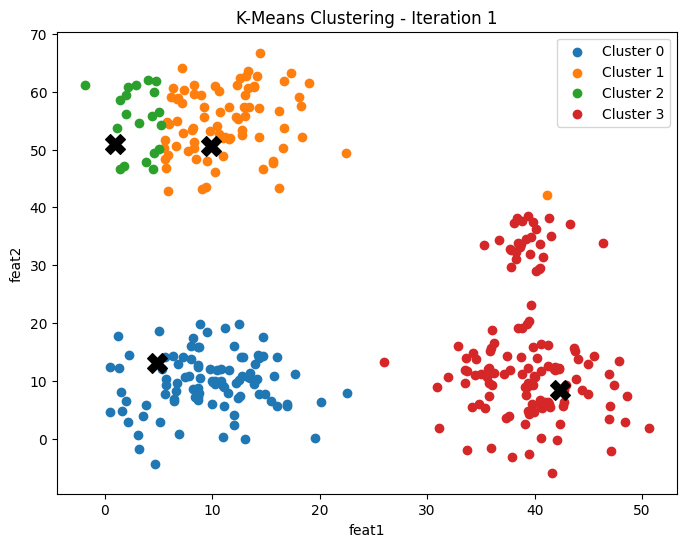

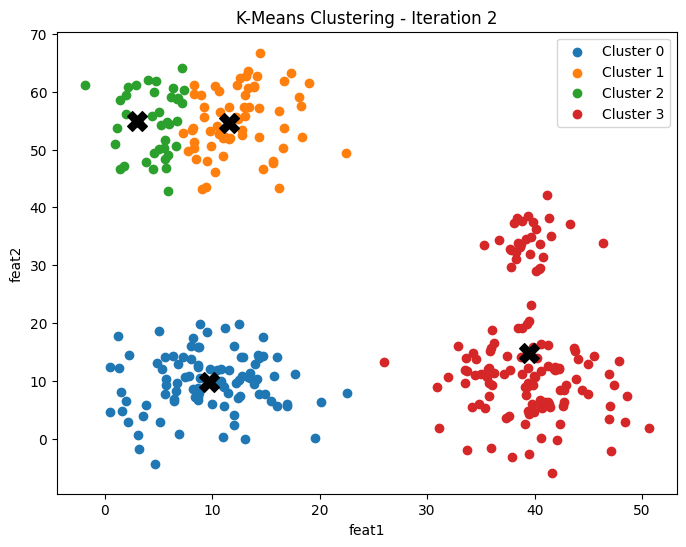

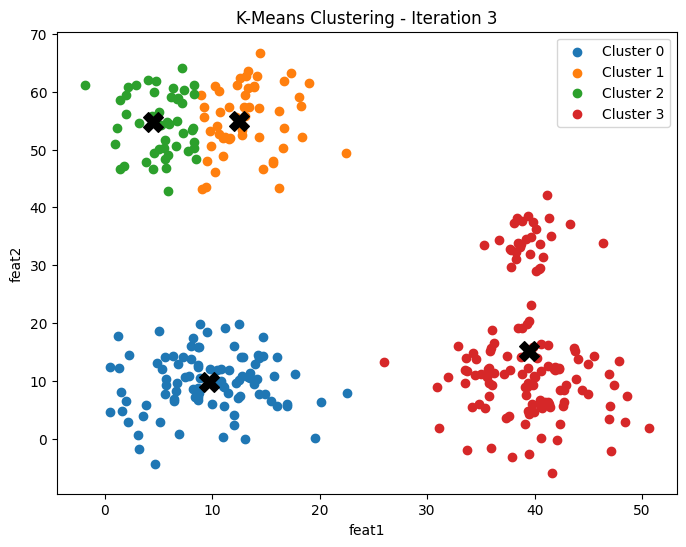

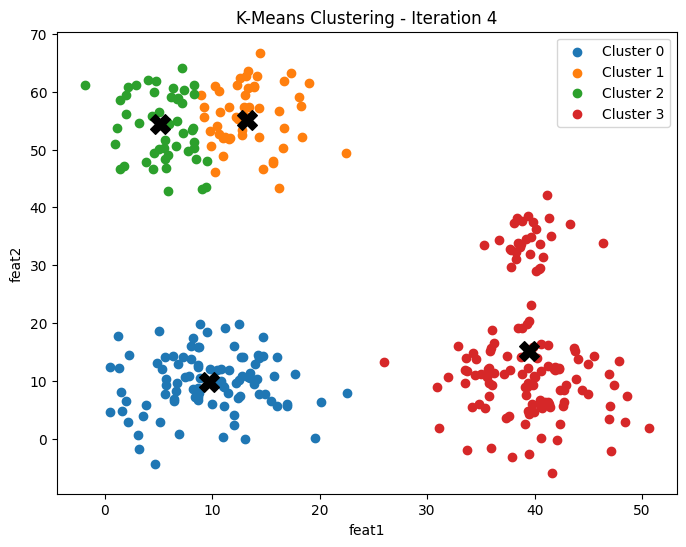

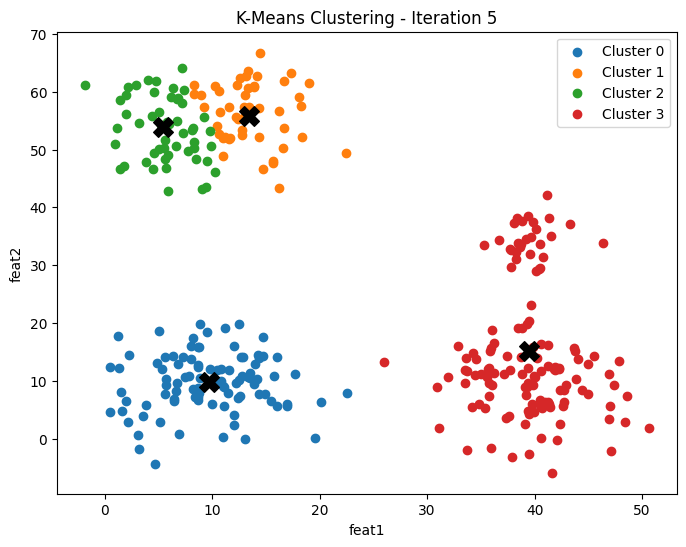

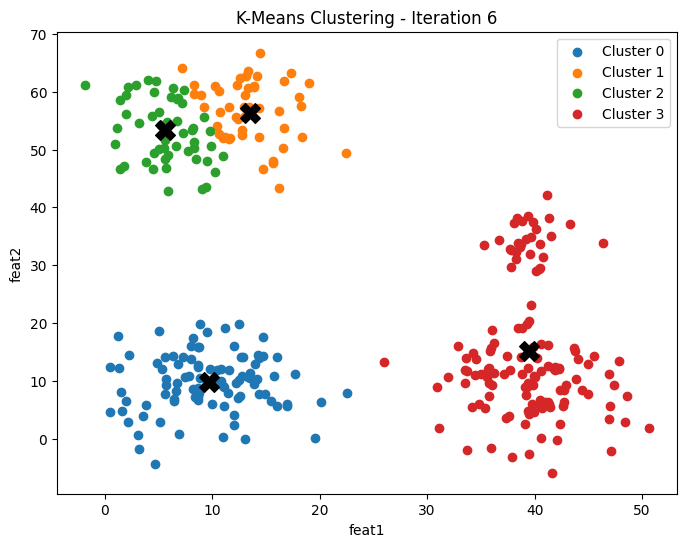

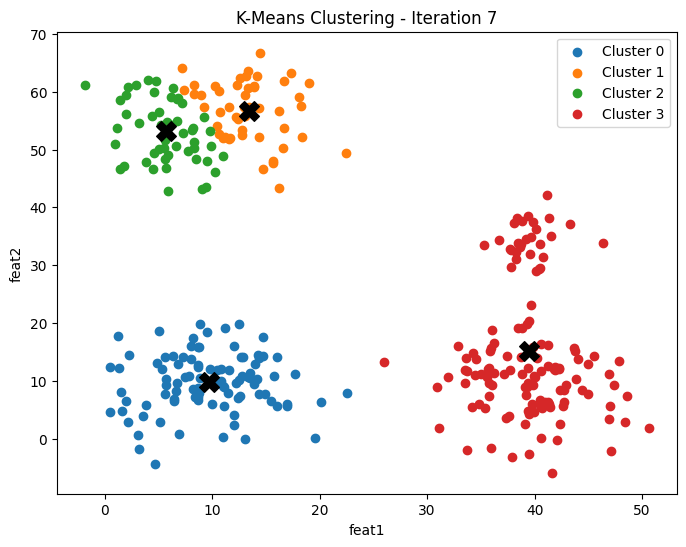

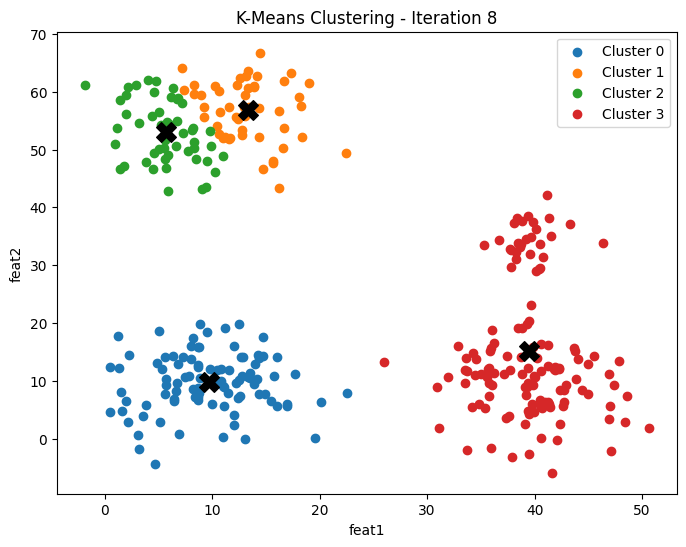

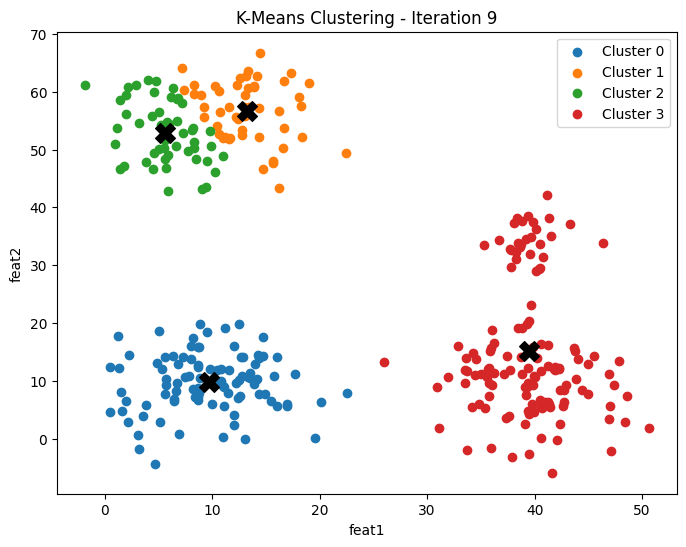

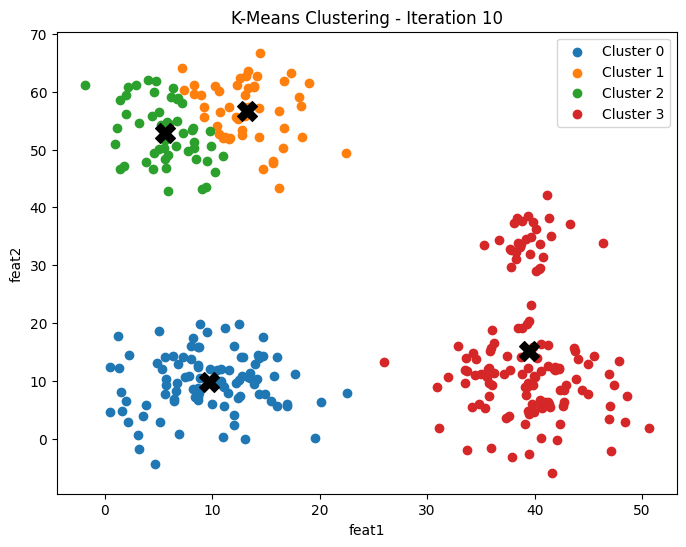

Converged after 10 iterations.


In [12]:
k = 4

init = [random.randint(0, len(X) - 1) for _ in range(k)] # Posição inicial dos clusters
df_x.loc[:, 'cluster'] = -1  # Inicializa a coluna de cluster com -1
df_x.loc[init, 'cluster'] = range(k)  # Atribui os clusters iniciais aos pontos selecionados

# Aplicar estratégia de K-Means
centroids_memory = [-1] * k  # Inicializa a memória dos centróides para verificar convergência

for iteration in range(10):  # Número de iterações
    # Calcular os centróides dos clusters
    centroids = calculate_centroids([X[df_x['cluster'] == i] for i in range(k)])

    # Atribuir cada ponto ao cluster mais próximo
    for index, row in df_x.iterrows():
        distances = [euclidean_distance(row[variables].values, centroids[i]) for i in range(k)]
        df_x.at[index, 'cluster'] = np.argmin(distances)

    # Plotar os clusters e centróides
    plt.figure(figsize=(8, 6))
    for i in range(k):
        cluster_points = df_x[df_x['cluster'] == i]
        plt.scatter(cluster_points['feat1'], cluster_points['feat2'], label=f'Cluster {i}')
        plt.scatter(centroids[i][0], centroids[i][1], marker='X', s=200, c='black')  # Centróide

    plt.xlabel('feat1')
    plt.ylabel('feat2')
    plt.title(f'K-Means Clustering - Iteration {iteration + 1}')
    plt.legend()
    plt.show()

    # Verificar se os centróides mudaram
    if np.array_equal(centroids, centroids_memory):
        print(f"Converged after {iteration + 1} iterations.")
        break

    centroids_memory = centroids

In [13]:
# Meu K-Means não conseguiu separar o cluster 4, que foi adicionado depois. Isso é esperado, pois o K-Means é 
# sensível à inicialização dos centróides e à presença de clusters sobrepostos ou próximos. Para melhorar a separação, 
# podemos tentar diferentes inicializações. Vou checar como o K-Medoids se comporta

# 04. K-Medoids

In [14]:
# Função para calcular o medoid
def calculate_medoid(cluster):
    distances = np.sum(np.linalg.norm(cluster[:, np.newaxis] - cluster, axis=2), axis=1)
    medoid_index = np.argmin(distances)
    return cluster[medoid_index]

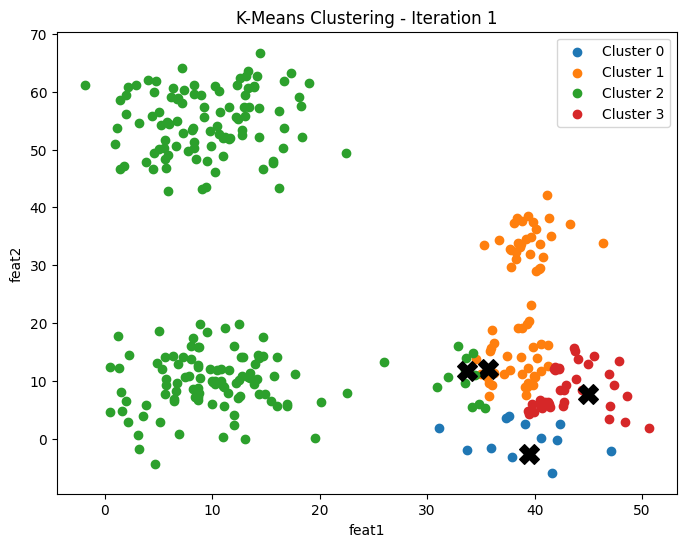

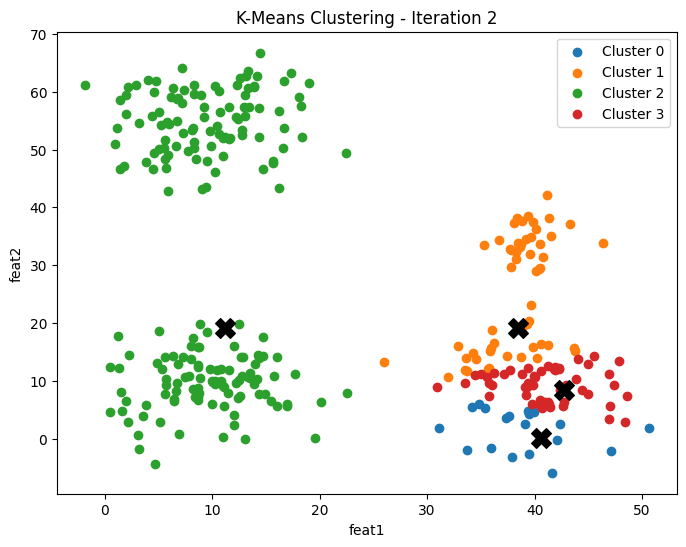

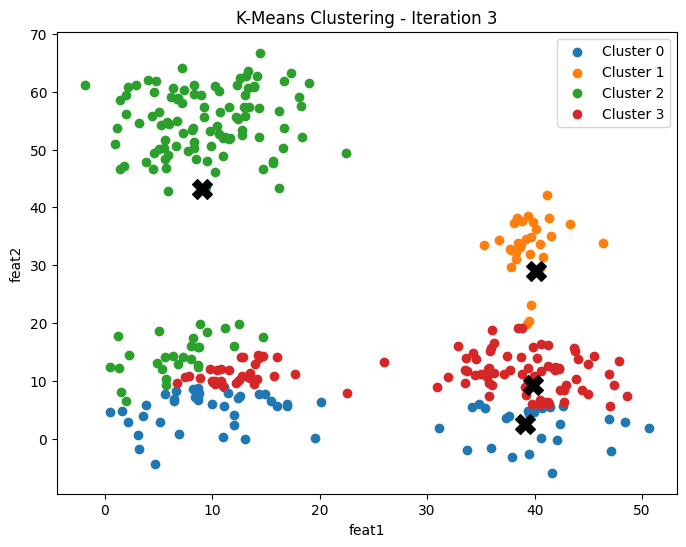

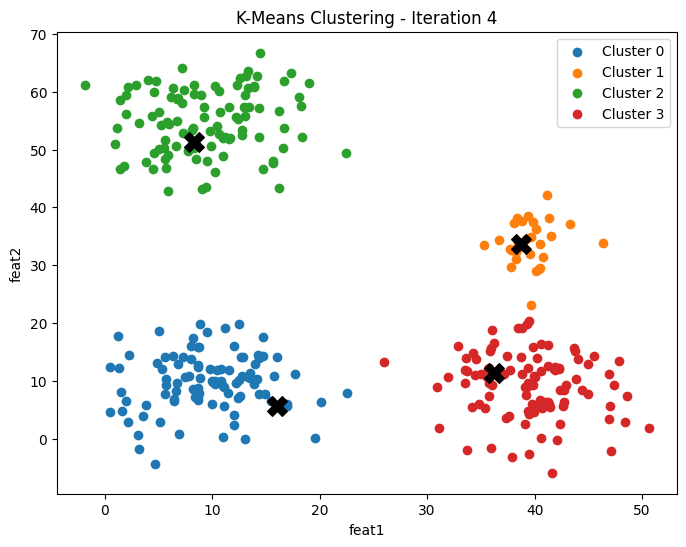

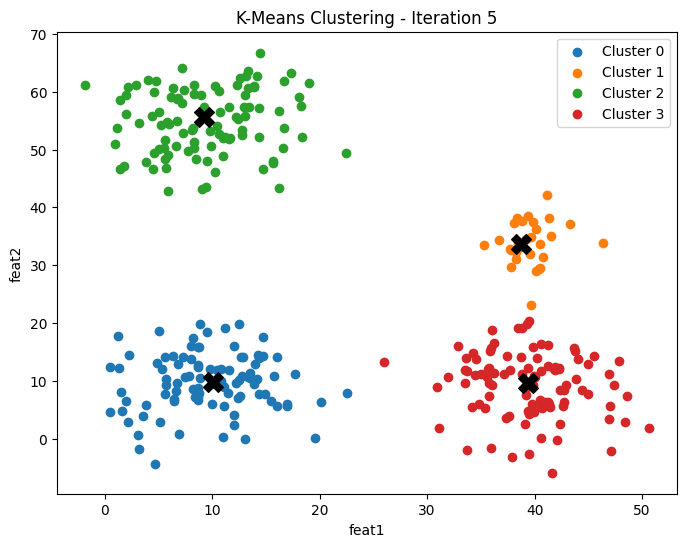

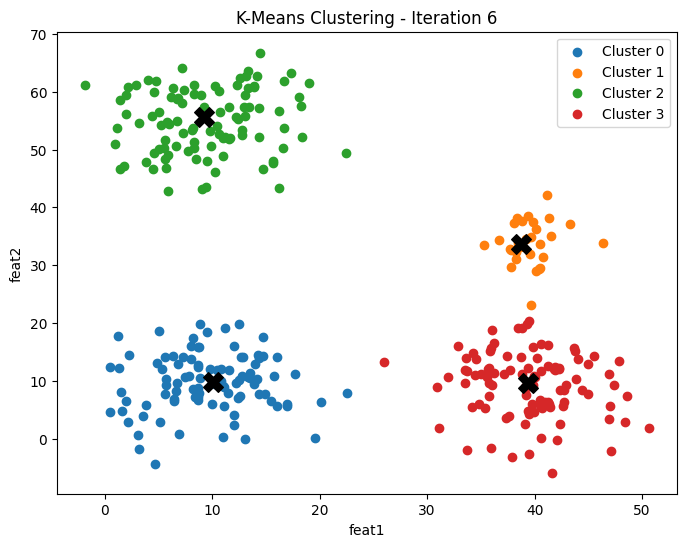

Converged after 6 iterations.


In [15]:
# Aplicação do K-Medoids
k = 4

init = [random.randint(0, len(X) - 1) for _ in range(k)] # Posição inicial dos clusters
df_x.loc[:, 'cluster'] = -1  # Inicializa a coluna de cluster com -1
df_x.loc[init, 'cluster'] = range(k)  # Atribui os clusters iniciais aos pontos selecionados

# Aplicar estratégia de K-Means
centroids_memory = [-1] * k  # Inicializa a memória dos centróides para verificar convergência

for iteration in range(10):  # Número de iterações
    # Calcular os centróides dos clusters
    centroids = list()
    for i in range(k):
        cluster = X[df_x['cluster'] == i]
        centroids.append(calculate_medoid(cluster))

    # Atribuir cada ponto ao cluster mais próximo
    for index, row in df_x.iterrows():
        distances = [euclidean_distance(row[variables].values, centroids[i]) for i in range(k)]
        df_x.at[index, 'cluster'] = np.argmin(distances)

    # Plotar os clusters e centróides
    plt.figure(figsize=(8, 6))
    for i in range(k):
        cluster_points = df_x[df_x['cluster'] == i]
        plt.scatter(cluster_points['feat1'], cluster_points['feat2'], label=f'Cluster {i}')
        plt.scatter(centroids[i][0], centroids[i][1], marker='X', s=200, c='black')  # Centróide

    plt.xlabel('feat1')
    plt.ylabel('feat2')
    plt.title(f'K-Means Clustering - Iteration {iteration + 1}')
    plt.legend()
    plt.show()

    # Verificar se os centróides mudaram
    if np.array_equal(centroids, centroids_memory):
        print(f"Converged after {iteration + 1} iterations.")
        break

    centroids_memory = centroids